# Image Classification

In [20]:
import json
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader, Subset

## Configuration

In [ ]:
# Simple variables
SEED = 42
BATCH_SIZE = 32
NUM_EPOCHS = 10
EARLY_STOP_PATIENCE = 4
LR = 3e-6
WEIGHT_DECAY = 1e-6
IMAGE_SIZE = 224
DETECTION_THRESHOLD = 0.50
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15
MODEL_PATH = Path('output/food-detector-model.pth')

# Setup
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


## Data Loading

In [22]:
def get_data_loaders(dataset_dir):
    dataset_dir = Path(dataset_dir)
    all_dataset = datasets.ImageFolder(dataset_dir)
    class_names = all_dataset.classes
    
    indices = np.arange(len(all_dataset))
    targets = np.array(all_dataset.targets)
    
    # 70% train
    train_idx, temp_idx = train_test_split(
        indices, test_size=1-TRAIN_RATIO, stratify=targets, random_state=SEED
    )
    
    # 10% val, 10% test
    temp_targets = targets[temp_idx]
    val_idx, test_idx = train_test_split(
        temp_idx, test_size=0.50, stratify=temp_targets, random_state=SEED
    )
    
    train_tfms = transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    
    eval_tfms = transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    
    train_ds = datasets.ImageFolder(dataset_dir, transform=train_tfms)
    train_ds = Subset(train_ds, train_idx)
    
    val_ds = datasets.ImageFolder(dataset_dir, transform=eval_tfms)
    val_ds = Subset(val_ds, val_idx)
    
    test_ds = datasets.ImageFolder(dataset_dir, transform=eval_tfms)
    test_ds = Subset(test_ds, test_idx)
    
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)
    
    return train_loader, val_loader, test_loader, class_names


dataset_dir = Path('dataset')
train_loader, val_loader, test_loader, class_names = get_data_loaders(dataset_dir)

print(f'Classes: {class_names}')
print(f'Train: {len(train_loader.dataset)}, Val: {len(val_loader.dataset)}, Test: {len(test_loader.dataset)}')

Classes: ['background', 'food', 'water']
Train: 1416, Val: 303, Test: 304


## Model

In [108]:
def build_model(num_classes):
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    model.fc = nn.Sequential(
        nn.Dropout(p=0.25),
        nn.Linear(model.fc.in_features, num_classes),
    )
    return model


model = build_model(len(class_names)).to(device)
print(f'Model: ResNet18, Classes: {len(class_names)}')

Model: ResNet18, Classes: 3


## Training

In [24]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    all_preds, all_labels = [], []
    
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * images.size(0)
        all_preds.extend(logits.argmax(dim=1).detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())
    
    avg_loss = total_loss / len(loader.dataset)
    accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
    return avg_loss, accuracy


def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []
    
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            logits = model(images)
            loss = criterion(logits, labels)
            total_loss += loss.item() * images.size(0)
            all_preds.extend(logits.argmax(dim=1).detach().cpu().numpy())
            all_labels.extend(labels.detach().cpu().numpy())
    
    avg_loss = total_loss / len(loader.dataset)
    accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
    return avg_loss, accuracy, np.array(all_labels), np.array(all_preds)

In [25]:
# Calculate class weights
train_targets = torch.tensor(train_loader.dataset.dataset.targets)[train_loader.dataset.indices]
class_counts = torch.bincount(train_targets, minlength=len(class_names)).float()
class_weights = class_counts.sum() / (class_counts + 1e-9)
class_weights = class_weights / class_weights.mean()
class_weights = class_weights.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.05)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)

history = []
best_acc = -1
patience_counter = 0

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, _, _ = eval_epoch(model, val_loader, criterion, device)
    scheduler.step(val_acc)
    
    history.append({
        'epoch': epoch,
        'train_loss': train_loss,
        'train_acc': train_acc,
        'val_loss': val_loss,
        'val_acc': val_acc,
    })
    
    if val_acc > best_acc:
        best_acc = val_acc
        patience_counter = 0
        torch.save({'model_state_dict': model.state_dict()}, MODEL_PATH)
    else:
        patience_counter += 1
    
    print(f"Epoch {epoch:02d} | train_loss {train_loss:.4f} train_acc {train_acc:.4f} | "
          f"val_loss {val_loss:.4f} val_acc {val_acc:.4f}")
    
    if patience_counter >= EARLY_STOP_PATIENCE:
        print('Early stopping')
        break

print(f'\nBest val acc: {best_acc:.4f}')
print(f'Saved: {MODEL_PATH}')

/home/sk/miniconda3/envs/ds/lib/python3.14/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 01 | train_loss 0.9939 train_acc 0.5847 | val_loss 0.7786 val_acc 0.8383
Epoch 02 | train_loss 0.6889 train_acc 0.8312 | val_loss 0.5387 val_acc 0.9637
Epoch 03 | train_loss 0.5260 train_acc 0.9202 | val_loss 0.4195 val_acc 0.9802
Epoch 04 | train_loss 0.4425 train_acc 0.9513 | val_loss 0.3462 val_acc 0.9934
Epoch 05 | train_loss 0.3871 train_acc 0.9626 | val_loss 0.3063 val_acc 1.0000
Epoch 06 | train_loss 0.3506 train_acc 0.9696 | val_loss 0.2829 val_acc 1.0000
Epoch 07 | train_loss 0.3267 train_acc 0.9767 | val_loss 0.2650 val_acc 1.0000
Epoch 08 | train_loss 0.3179 train_acc 0.9788 | val_loss 0.2599 val_acc 1.0000
Epoch 09 | train_loss 0.3077 train_acc 0.9767 | val_loss 0.2531 val_acc 1.0000
Early stopping

Best val acc: 1.0000
Saved: output/detect.pth


## Evaluation

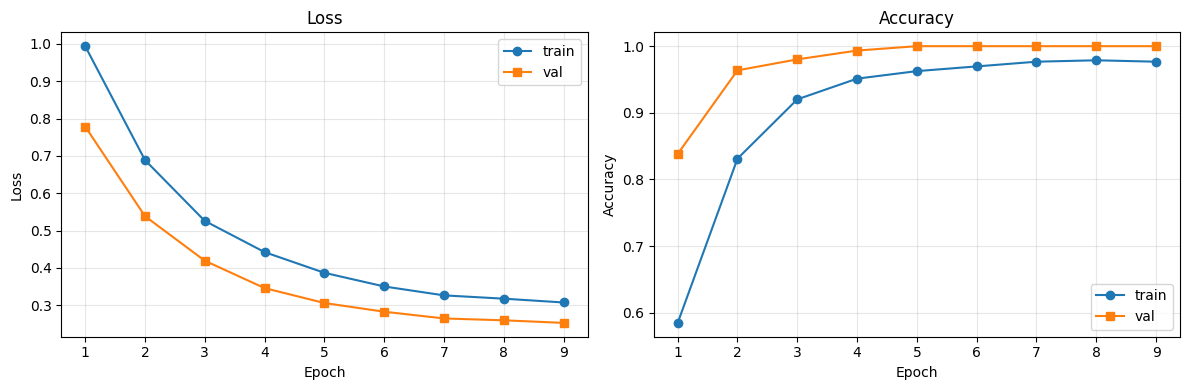

In [32]:
# Plot history
epochs = [h['epoch'] for h in history]
train_loss = [h['train_loss'] for h in history]
val_loss = [h['val_loss'] for h in history]
train_acc = [h['train_acc'] for h in history]
val_acc = [h['val_acc'] for h in history]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, train_loss, label='train', marker='o')
axes[0].plot(epochs, val_loss, label='val', marker='s')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, train_acc, label='train', marker='o')
axes[1].plot(epochs, val_acc, label='val', marker='s')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [33]:
# Test evaluation
test_loss, test_acc, y_true, y_pred = eval_epoch(model, test_loader, criterion, device)
print(f'Test Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_acc:.4f}')

Test Loss: 0.2745
Test Accuracy: 0.9836


/home/sk/miniconda3/envs/ds/lib/python3.14/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


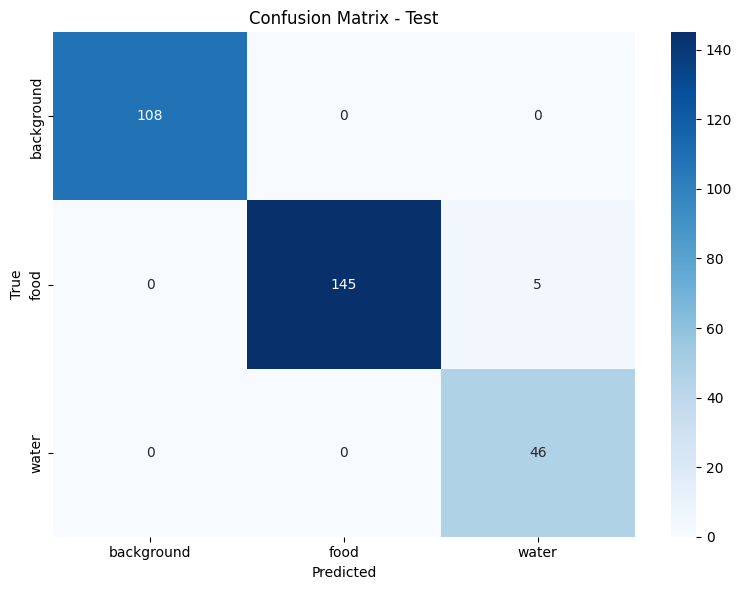

In [34]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Test')
plt.tight_layout()
plt.show()

In [35]:
# Classification report
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

              precision    recall  f1-score   support

  background     1.0000    1.0000    1.0000       108
        food     1.0000    0.9667    0.9831       150
       water     0.9020    1.0000    0.9485        46

    accuracy                         0.9836       304
   macro avg     0.9673    0.9889    0.9772       304
weighted avg     0.9852    0.9836    0.9838       304



## Prediction

In [36]:
def predict_image(image_path):
    image = Image.open(image_path).convert('RGB')
    
    tfms = transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    
    x = tfms(image).unsqueeze(0).to(device)
    model.eval()
    
    with torch.no_grad():
        logits = model(x)
        probs = torch.softmax(logits, dim=1).squeeze(0).cpu().numpy()
    
    probs_dict = {class_names[i]: float(probs[i] * 100.0) for i in range(len(class_names))}
    pred_class = class_names[probs.argmax()]
    
    return pred_class, probs_dict


In [42]:
path = "Image.jpeg"
pred_class, probs = predict_image(path)
print({
    'image': str(path),
    'predicted_class': pred_class,
    'confidence': float(probs[pred_class]),
    'probabilities': {k: round(v, 2) for k, v in probs.items()},
})

{'image': 'Image.jpeg', 'predicted_class': 'water', 'confidence': 48.26846694946289, 'probabilities': {'background': 24.43, 'food': 27.3, 'water': 48.27}}
